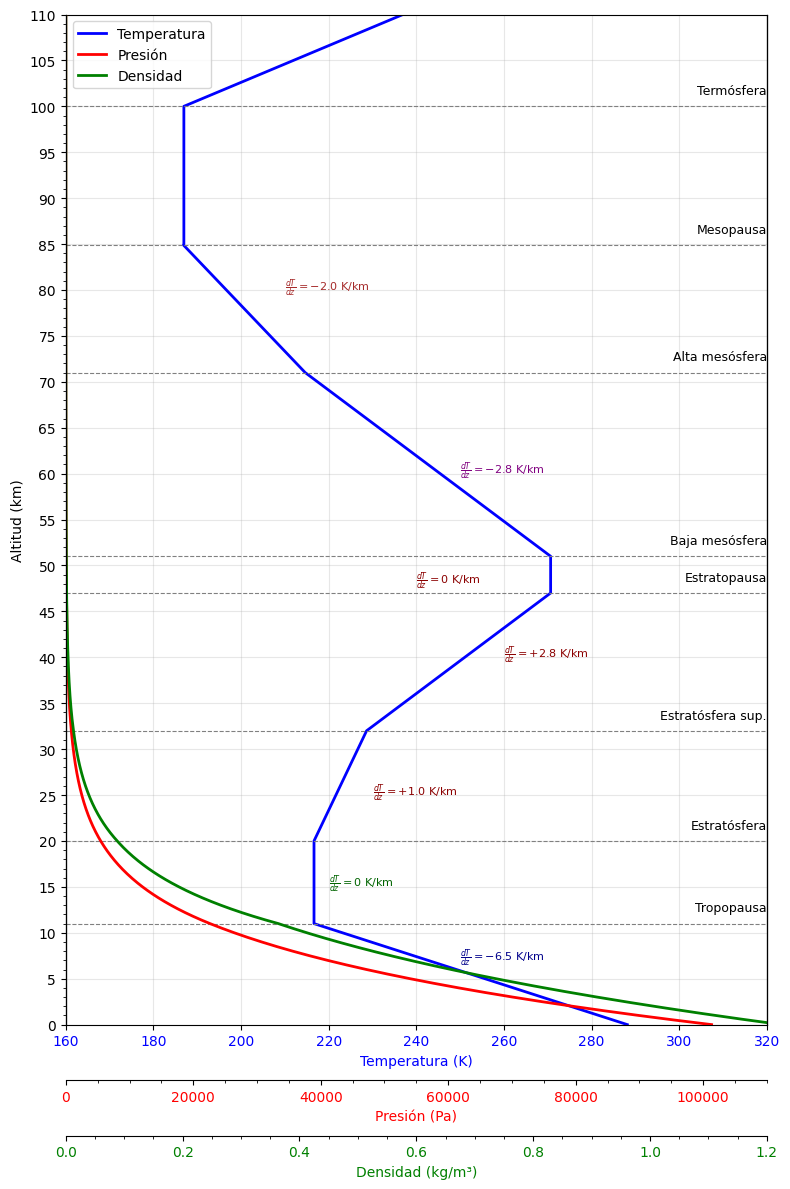

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

# ============================================================
# Constantes y definición de capas (hasta 110 km)
# Cada capa tiene: altura inferior (m), altura superior (m),
# gradiente térmico (K/m), y temperatura base (K) en el límite inferior.
# ============================================================
g = 9.80665        # m/s²
R = 287.05         # J/(kg·K)

capas = [
    # (z_min, z_max, lapse, T_base)
    (0, 11000, -0.0065, 288.15),      # Tropósfera
    (11000, 20000, 0.0, 216.65),      # Estratósfera inferior (isoterma)
    (20000, 32000, 0.001, 216.65),    # Estratósfera superior (gradiente +)
    (32000, 47000, 0.0028, 228.65),   # Estratósfera superior (gradiente + mayor)
    (47000, 51000, 0.0, 270.65),      # Mesósfera baja (isoterma)
    (51000, 71000, -0.0028, 270.65),  # Mesósfera media (gradiente -)
    (71000, 84900, -0.002, 214.65),   # Mesósfera alta (gradiente - más suave)
    (84900, 100000, 0.0, 186.95),     # Mesopausa (isoterma)
    (100000, 110000, 0.005, 186.95),  # Termósfera inferior (gradiente +)
]

# ============================================================
# Generar vector de alturas (0 a 110 km, paso 100 m)
# ============================================================
z_m = np.arange(0, 110001, 100)  # metros
z_km = z_m / 1000.0               # kilómetros
n = len(z_m)

# Inicializar arreglos
T = np.zeros(n)
P = np.zeros(n)
rho = np.zeros(n)

# Condición inicial en superficie
P[0] = 101325.0  # Pa
T[0] = 288.15    # K
rho[0] = P[0] / (R * T[0])

# Integración numérica paso a paso de la ecuación hidrostática
for i in range(1, n):
    z_actual = z_m[i]
    z_prev = z_m[i-1]
    dz = z_actual - z_prev   # 100 m

    # Determinar la capa correspondiente a la altura actual y calcular T
    for (z_min, z_max, lapse, T_base) in capas:
        if z_min <= z_actual <= z_max:
            T[i] = T_base + lapse * (z_actual - z_min)
            break

    # Presión usando temperatura promedio entre puntos
    T_mean = (T[i-1] + T[i]) / 2.0
    P[i] = P[i-1] * np.exp(-g / (R * T_mean) * dz)

    # Densidad
    rho[i] = P[i] / (R * T[i])

# ============================================================
# Graficación
# ============================================================
fig, ax = plt.subplots(figsize=(8, 12))

# Eje principal: temperatura (escala lineal)
ax.plot(T, z_km, 'b-', linewidth=2, label='Temperatura')
ax.set_xlabel('Temperatura (K)', color='blue')
ax.set_ylabel('Altitud (km)')
ax.tick_params(axis='x', labelcolor='blue')
ax.set_xlim(160, 320)
ax.set_ylim(110, 0)
ax.invert_yaxis()
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_minor_locator(MultipleLocator(1))
ax.grid(True, alpha=0.3)

# Eje para presión (rojo) - escala lineal
ax2 = ax.twiny()
ax2.plot(P, z_km, 'r-', linewidth=2, label='Presión')
ax2.spines['top'].set_visible(False)
ax2.spines['bottom'].set_position(('outward', 40))
ax2.xaxis.set_ticks_position('bottom')
ax2.xaxis.set_label_position('bottom')
ax2.set_xlabel('Presión (Pa)', color='red')
ax2.tick_params(axis='x', labelcolor='red')
ax2.set_xlim(0, 110000)
ax2.xaxis.set_major_locator(MultipleLocator(20000))
ax2.xaxis.set_minor_locator(AutoMinorLocator())

# Eje para densidad (verde) - escala lineal, rango 0 a 1.2
ax3 = ax.twiny()
ax3.plot(rho, z_km, 'g-', linewidth=2, label='Densidad')
ax3.spines['top'].set_visible(False)
ax3.spines['bottom'].set_position(('outward', 80))
ax3.xaxis.set_ticks_position('bottom')
ax3.xaxis.set_label_position('bottom')
ax3.set_xlabel('Densidad (kg/m³)', color='green')
ax3.tick_params(axis='x', labelcolor='green')
ax3.set_xlim(0, 1.2)
ax3.xaxis.set_major_locator(MultipleLocator(0.2))
ax3.xaxis.set_minor_locator(AutoMinorLocator())

# ============================================================
# Marcar capas y anotaciones
# ============================================================
limites_km = [11, 20, 32, 47, 51, 71, 84.9, 100]
etiquetas = {
    11: 'Tropopausa',
    20: 'Estratósfera',
    32: 'Estratósfera sup.',
    47: 'Estratopausa',
    51: 'Baja mesósfera',
    71: 'Alta mesósfera',
    84.9: 'Mesopausa',
    100: 'Termósfera'
}
for h in limites_km:
    ax.axhline(y=h, color='gray', linestyle='--', linewidth=0.8)
    if h in etiquetas:
        ax.text(320, h+1, etiquetas[h], fontsize=9, ha='right', va='bottom')

# Anotaciones de gradientes
ax.text(250, 7, r'$\frac{dT}{dz} = -6.5$ K/km', fontsize=8, color='darkblue')
ax.text(220, 15, r'$\frac{dT}{dz} = 0$ K/km', fontsize=8, color='darkgreen')
ax.text(230, 25, r'$\frac{dT}{dz} = +1.0$ K/km', fontsize=8, color='darkred')
ax.text(260, 40, r'$\frac{dT}{dz} = +2.8$ K/km', fontsize=8, color='darkred')
ax.text(240, 48, r'$\frac{dT}{dz} = 0$ K/km', fontsize=8, color='darkred')
ax.text(250, 60, r'$\frac{dT}{dz} = -2.8$ K/km', fontsize=8, color='purple')
ax.text(210, 80, r'$\frac{dT}{dz} = -2.0$ K/km', fontsize=8, color='brown')

# Leyenda combinada
lines = [ax.get_lines()[0], ax2.get_lines()[0], ax3.get_lines()[0]]
labels = ['Temperatura', 'Presión', 'Densidad']
ax.legend(lines, labels, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()